## AI-Based Support Ticket Classification **System**

## Introduction

Customer support systems receive thousands of support tickets daily.
Manually handling and categorizing these tickets takes time and effort.

This project uses Machine Learning and Natural Language Processing (NLP)
to automatically classify support tickets into categories and predict
their priority levels.

## Objective

The main objectives of this project are:

- Automate support ticket classification
- Predict ticket priority levels
- Reduce manual effort
- Learn NLP and Machine Learning concepts
- Analyze customer support data

## Technologies Used

- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib
- Seaborn
- NLP Techniques

In [247]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression


In [248]:
df = pd.read_csv('support_tickets.csv')
df.head()


,ticket_id,text,category,priority
0,1,I cannot log into my account. It keeps saying ...,login_issue,high
1,2,My payment was charged twice for the same orde...,billing,high
2,3,The mobile app crashes every time I try to ope...,bug_report,high
3,4,Can you add a dark mode option to the dashboar...,feature_request,low
4,5,I forgot my username. How can I recover it?,login_issue,medium


In [249]:
def clean_text(text):

    # Convert into lowercase
    text = text.lower()

    # Remove special characters
    text = re.sub(r'[^a-zA-Z ]', '', text)

    return text


In [250]:
#Apply Cleaning
df["clean_text"] = df["text"].apply(clean_text)

In [251]:
vectorizer = TfidfVectorizer(stop_words='english')

X = vectorizer.fit_transform(df["clean_text"])


In [252]:
# Output labels
y = df["category"]


In [253]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [254]:
#Train Model
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("\nModel Trained Successfully")



Model Trained Successfully


In [255]:
#Prediction
y_pred = model.predict(X_test)

In [256]:
#Model Accuracy

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy :", accuracy)

Accuracy : 0.1


In [257]:
# Full report
print(classification_report(y_test, y_pred))


                 precision    recall  f1-score   support

        billing       0.00      0.00      0.00         0
     bug_report       1.00      0.33      0.50         3
feature_request       0.00      0.00      0.00         3
general_inquiry       0.00      0.00      0.00         1
    login_issue       0.00      0.00      0.00         1
       shipping       0.00      0.00      0.00         2

       accuracy                           0.10        10
      macro avg       0.17      0.06      0.08        10
   weighted avg       0.30      0.10      0.15        10



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [258]:
# CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred)

In [259]:
new_ticket = ["Payment failed and amount deducted"]

In [260]:
# Clean text
cleaned_ticket = [clean_text(new_ticket[0])]

In [261]:
# Convert into vector
vector_ticket = vectorizer.transform(cleaned_ticket)


In [262]:
# Predict category
prediction = model.predict(vector_ticket)


In [263]:
print("Predicted Category :", prediction[0])

Predicted Category : billing


In [264]:
def get_priority(text):

    text = text.lower()

    if "failed" in text or "crash" in text:
        return "High"

    elif "issue" in text or "problem" in text:
        return "Medium"

    else:
        return "Low"

 # USER INPUT

print("\n-----------------------------------")

print("SUPPORT TICKET PREDICTION SYSTEM")

print("-----------------------------------")

user_input = input("\nEnter Support Ticket Text:\n")

# Clean Input
cleaned_input = clean_text(user_input)

# Vectorize Input
vector_input = vectorizer.transform([cleaned_input])

# Prediction
prediction = model.predict(vector_input)[0]

# Priority
priority = get_priority(user_input)

# -----------------------------------
# FINAL OUTPUT
# -----------------------------------

print("\n-----------------------------------")

print("PREDICTION RESULT")

print("-----------------------------------")

print("Predicted Category:", prediction)

print("Ticket Priority:", priority)

print("-----------------------------------")


-----------------------------------
SUPPORT TICKET PREDICTION SYSTEM
-----------------------------------

Enter Support Ticket Text:
3

-----------------------------------
PREDICTION RESULT
-----------------------------------
Predicted Category: billing
Ticket Priority: Low
-----------------------------------


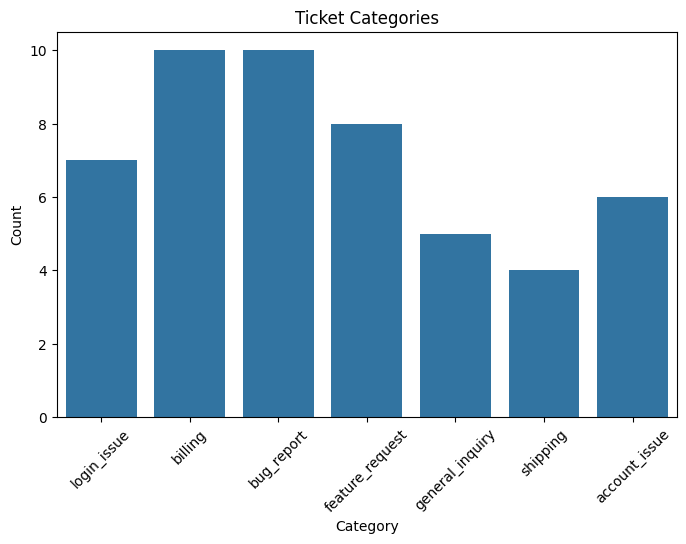

<Figure size 640x480 with 0 Axes>

In [265]:
plt.figure(figsize=(8,5))

sns.countplot(x=df["category"])

plt.title("Ticket Categories")
plt.xlabel("Category")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()
plt.savefig("category_graph.png")

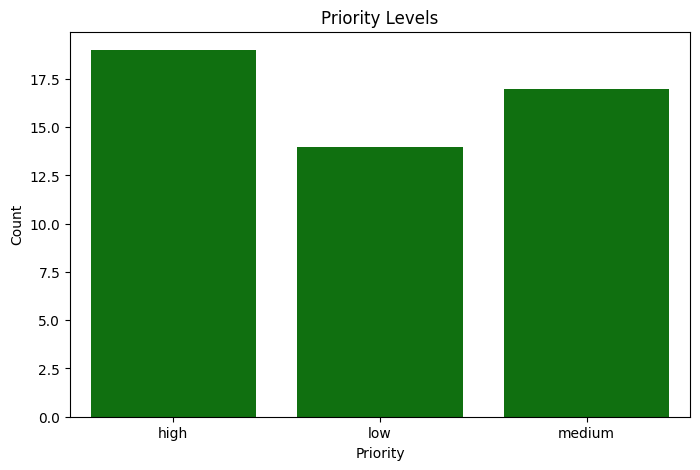

In [266]:
plt.figure(figsize=(8,5))

sns.countplot(x=df["priority"],color='green')

plt.title("Priority Levels")
plt.xlabel("Priority")
plt.ylabel("Count")

plt.show()

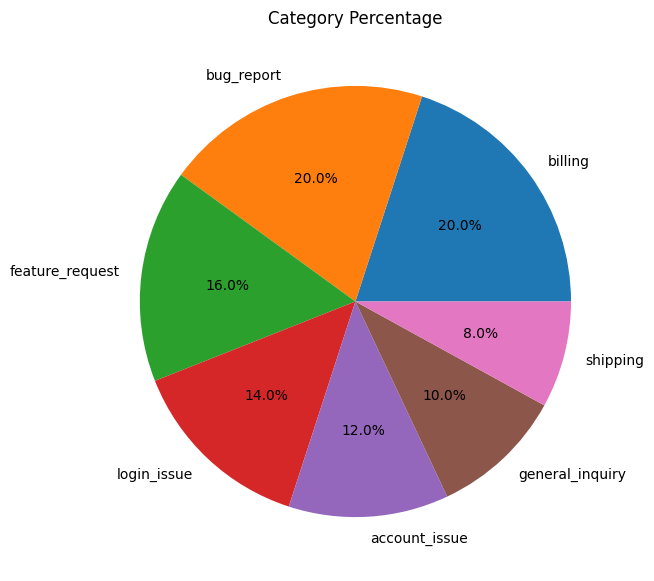

In [267]:
category_counts = df["category"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    category_counts,
    labels=category_counts.index,
    autopct="%1.1f%%"
)

plt.title("Category Percentage")

plt.show()

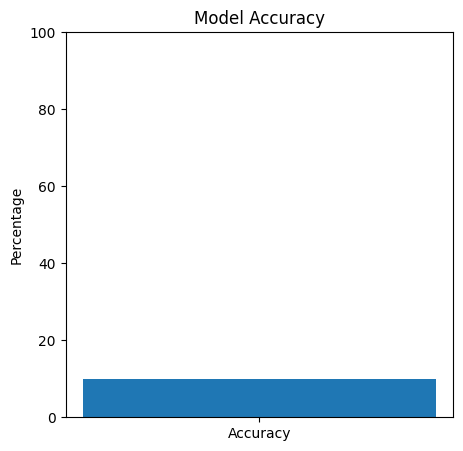

In [268]:
accuracy_percent = accuracy * 100

plt.figure(figsize=(5,5))

plt.bar(
    ["Accuracy"],
    [accuracy_percent]
)

plt.ylabel("Percentage")
plt.title("Model Accuracy")

plt.ylim(0,100)

plt.show()


In [269]:
from sklearn.metrics import confusion_matrix

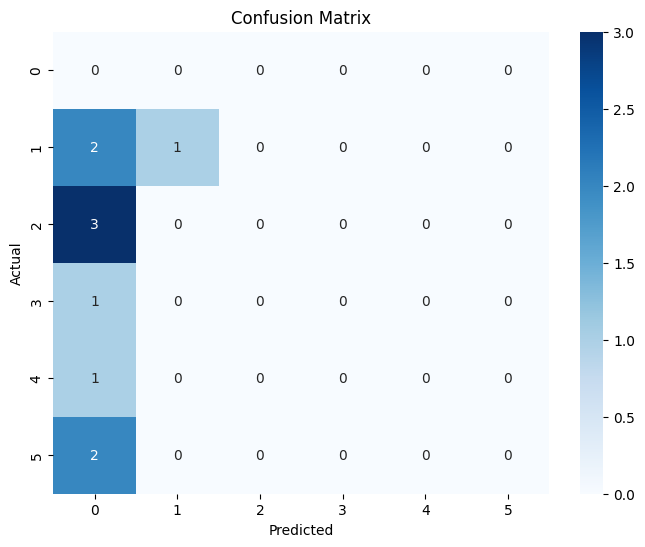

In [270]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()